# 04 — Modeling: FH RSL Link Status Classification

**Goal:** Train a classifier to predict `Status` (Lien_OK / dépointé_<10 / dépointé_>10)
from RSL-based features.

**Input:** `data/processed/fh_rsl_features.csv`

Load data and select features

In [2]:
import pandas as pd
from pathlib import Path

PROCESSED_DIR = Path("../data/processed")
df = pd.read_csv(PROCESSED_DIR / "fh_rsl_features.csv")

print(df.shape)
print(df.columns.tolist())
print(df["Status"].value_counts())

(1292, 9)
['Status', 'IP', 'Max RSL', 'RSL REF', 'RSL DIFF', 'Name', 'File', 'Comment', 'Max RSL_was_sentinel']
Status
Lien_OK                855
Lien_dépointé_(<10)    238
Lien_dépointé_(>10)    199
Name: count, dtype: int64


Build the train/test split — stratified, since we know the classes are imbalanced

In [3]:
from sklearn.model_selection import train_test_split

feature_cols = ["Max RSL", "RSL REF", "RSL DIFF", "Max RSL_was_sentinel"]
X = df[feature_cols]
y = df["Status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("train:", X_train.shape, "test:", X_test.shape)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

train: (1033, 4) test: (259, 4)
Status
Lien_OK                0.662149
Lien_dépointé_(<10)    0.183930
Lien_dépointé_(>10)    0.153921
Name: proportion, dtype: float64
Status
Lien_OK                0.660232
Lien_dépointé_(<10)    0.185328
Lien_dépointé_(>10)    0.154440
Name: proportion, dtype: float64


Train a baseline model — Logistic Regression (simple, interpretable, good sanity-check baseline before anything fancier)

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline

baseline = make_pipeline(
    SimpleImputer(strategy="median"),
    LogisticRegression(max_iter=1000, class_weight="balanced")
)
baseline.fit(X_train, y_train)

y_pred = baseline.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

                     precision    recall  f1-score   support

            Lien_OK       1.00      0.98      0.99       171
Lien_dépointé_(<10)       0.96      1.00      0.98        48
Lien_dépointé_(>10)       0.95      1.00      0.98        40

           accuracy                           0.98       259
          macro avg       0.97      0.99      0.98       259
       weighted avg       0.99      0.98      0.98       259

[[167   2   2]
 [  0  48   0]
 [  0   0  40]]


Train a stronger model — Random Forest (handles non-linear relationships, no need to impute or scale)

In [5]:
from sklearn.ensemble import RandomForestClassifier

X_train_filled = X_train.fillna(X_train.median())
X_test_filled = X_test.fillna(X_train.median())

rf = RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42)
rf.fit(X_train_filled, y_train)

y_pred_rf = rf.predict(X_test_filled)
print(classification_report(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))

                     precision    recall  f1-score   support

            Lien_OK       1.00      0.99      0.99       171
Lien_dépointé_(<10)       1.00      1.00      1.00        48
Lien_dépointé_(>10)       0.95      1.00      0.98        40

           accuracy                           0.99       259
          macro avg       0.98      1.00      0.99       259
       weighted avg       0.99      0.99      0.99       259

[[169   0   2]
 [  0  48   0]
 [  0   0  40]]


In [6]:
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
print(importances)

RSL DIFF                0.786181
RSL REF                 0.123644
Max RSL                 0.087205
Max RSL_was_sentinel    0.002970
dtype: float64


In [7]:
import joblib

model_path = Path("../models/fh_rsl_classifier.pkl")
model_path.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(rf, model_path)
print("saved to:", model_path.resolve())

saved to: C:\OrangeCopilot\projet_pfe-main (1)\projet_pfe-main\main\FH\AI\models\fh_rsl_classifier.pkl


XGBoost on fh_rsl (reuses your existing X_train, X_test, y_train, y_test from the fh_rsl section)

In [8]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# XGBoost needs numeric labels, not strings — encode them
le_fh = LabelEncoder()
y_train_enc = le_fh.fit_transform(y_train)
y_test_enc = le_fh.transform(y_test)

X_train_filled = X_train.fillna(X_train.median())
X_test_filled = X_test.fillna(X_train.median())

xgb_fh = XGBClassifier(n_estimators=200, random_state=42, eval_metric="mlogloss")
xgb_fh.fit(X_train_filled, y_train_enc)

y_pred_xgb = xgb_fh.predict(X_test_filled)
y_pred_xgb_labels = le_fh.inverse_transform(y_pred_xgb)

print(classification_report(y_test, y_pred_xgb_labels))
print(confusion_matrix(y_test, y_pred_xgb_labels))

                     precision    recall  f1-score   support

            Lien_OK       0.99      0.99      0.99       171
Lien_dépointé_(<10)       1.00      0.98      0.99        48
Lien_dépointé_(>10)       0.95      1.00      0.98        40

           accuracy                           0.99       259
          macro avg       0.98      0.99      0.99       259
       weighted avg       0.99      0.99      0.99       259

[[169   0   2]
 [  1  47   0]
 [  0   0  40]]


# Modeling: Sanity Classification
**Goal:** Predict `Sanity` (CURATIVE / PREVENTIVE / OK) from RSL and error-count features.
**Input:** data/processed/sanity_features.csv

1. Load data and pick features

In [9]:
df_sanity = pd.read_csv(PROCESSED_DIR / "sanity_features.csv")
print(df_sanity.shape)
print(df_sanity.columns.tolist())
print(df_sanity["Sanity"].value_counts())

(6038, 18)
['IP', 'Slot', 'Sanity', 'Mod (Ref)', 'Mod (Min)', 'UAS', 'SEP', 'SES', 'ES', 'BBE', 'OFS', 'RSL (Min)', 'RSL (Max)', 'RSL (Avg)', 'RSL (Min)_was_sentinel', 'RSL (Max)_was_sentinel', 'RSL (Avg)_was_sentinel', 'rsl_range']
Sanity
PREVENTIVE    2571
CURATIVE      2352
OK            1115
Name: count, dtype: int64


2. Select features and split

In [10]:
feature_cols_sanity = [
    "RSL (Min)", "RSL (Max)", "RSL (Avg)", "rsl_range",
    "UAS", "SEP", "SES", "ES", "BBE", "OFS",
    "RSL (Min)_was_sentinel", "RSL (Max)_was_sentinel", "RSL (Avg)_was_sentinel",
]
X_sanity = df_sanity[feature_cols_sanity]
y_sanity = df_sanity["Sanity"]

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_sanity, y_sanity, test_size=0.2, random_state=42, stratify=y_sanity
)

print("train:", X_train_s.shape, "test:", X_test_s.shape)

train: (4830, 13) test: (1208, 13)


3. Baseline — Logistic Regression

In [11]:
baseline_sanity = make_pipeline(
    SimpleImputer(strategy="median"),
    LogisticRegression(max_iter=1000, class_weight="balanced")
)
baseline_sanity.fit(X_train_s, y_train_s)

y_pred_s = baseline_sanity.predict(X_test_s)
print(classification_report(y_test_s, y_pred_s))
print(confusion_matrix(y_test_s, y_pred_s))

              precision    recall  f1-score   support

    CURATIVE       0.69      0.67      0.68       471
          OK       0.69      1.00      0.81       223
  PREVENTIVE       0.64      0.53      0.58       514

    accuracy                           0.67      1208
   macro avg       0.67      0.73      0.69      1208
weighted avg       0.67      0.67      0.66      1208

[[316   0 155]
 [  0 223   0]
 [139 102 273]]


c:\OrangeCopilot\projet_pfe-main (1)\projet_pfe-main\main\FH\AI\.venv-ai\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


4. Random Forest

In [12]:
X_train_s_filled = X_train_s.fillna(X_train_s.median())
X_test_s_filled = X_test_s.fillna(X_train_s.median())

rf_sanity = RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42)
rf_sanity.fit(X_train_s_filled, y_train_s)

y_pred_rf_s = rf_sanity.predict(X_test_s_filled)
print(classification_report(y_test_s, y_pred_rf_s))
print(confusion_matrix(y_test_s, y_pred_rf_s))

              precision    recall  f1-score   support

    CURATIVE       0.88      0.98      0.93       471
          OK       0.98      1.00      0.99       223
  PREVENTIVE       0.98      0.87      0.92       514

    accuracy                           0.94      1208
   macro avg       0.95      0.95      0.95      1208
weighted avg       0.94      0.94      0.94      1208

[[462   0   9]
 [  0 223   0]
 [ 63   5 446]]


5. Feature importance

In [13]:
importances_s = pd.Series(rf_sanity.feature_importances_, index=feature_cols_sanity).sort_values(ascending=False)
print(importances_s)

UAS                       0.268864
RSL (Min)                 0.182211
RSL (Avg)                 0.127607
OFS                       0.122420
rsl_range                 0.119245
ES                        0.058521
BBE                       0.046454
RSL (Max)                 0.026206
SES                       0.015559
RSL (Min)_was_sentinel    0.013355
RSL (Max)_was_sentinel    0.009626
SEP                       0.007463
RSL (Avg)_was_sentinel    0.002469
dtype: float64


In [14]:
print(classification_report(y_test_s, y_pred_rf_s))
print(confusion_matrix(y_test_s, y_pred_rf_s))

              precision    recall  f1-score   support

    CURATIVE       0.88      0.98      0.93       471
          OK       0.98      1.00      0.99       223
  PREVENTIVE       0.98      0.87      0.92       514

    accuracy                           0.94      1208
   macro avg       0.95      0.95      0.95      1208
weighted avg       0.94      0.94      0.94      1208

[[462   0   9]
 [  0 223   0]
 [ 63   5 446]]


In [15]:
model_path_sanity = Path("../models/sanity_classifier.pkl")
joblib.dump(rf_sanity, model_path_sanity)
print("saved to:", model_path_sanity.resolve())

saved to: C:\OrangeCopilot\projet_pfe-main (1)\projet_pfe-main\main\FH\AI\models\sanity_classifier.pkl


XGBoost on sanity (reuses X_train_s, X_test_s, y_train_s, y_test_s)

In [16]:
le_sanity = LabelEncoder()
y_train_s_enc = le_sanity.fit_transform(y_train_s)
y_test_s_enc = le_sanity.transform(y_test_s)

X_train_s_filled = X_train_s.fillna(X_train_s.median())
X_test_s_filled = X_test_s.fillna(X_train_s.median())

xgb_sanity = XGBClassifier(n_estimators=200, random_state=42, eval_metric="mlogloss")
xgb_sanity.fit(X_train_s_filled, y_train_s_enc)

y_pred_xgb_s = xgb_sanity.predict(X_test_s_filled)
y_pred_xgb_s_labels = le_sanity.inverse_transform(y_pred_xgb_s)

print(classification_report(y_test_s, y_pred_xgb_s_labels))
print(confusion_matrix(y_test_s, y_pred_xgb_s_labels))

              precision    recall  f1-score   support

    CURATIVE       0.89      0.96      0.92       471
          OK       0.97      1.00      0.99       223
  PREVENTIVE       0.96      0.88      0.92       514

    accuracy                           0.93      1208
   macro avg       0.94      0.95      0.94      1208
weighted avg       0.93      0.93      0.93      1208

[[452   0  19]
 [  0 223   0]
 [ 57   6 451]]


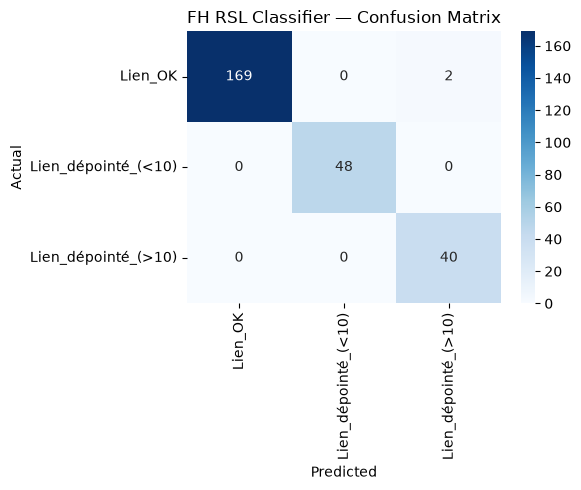

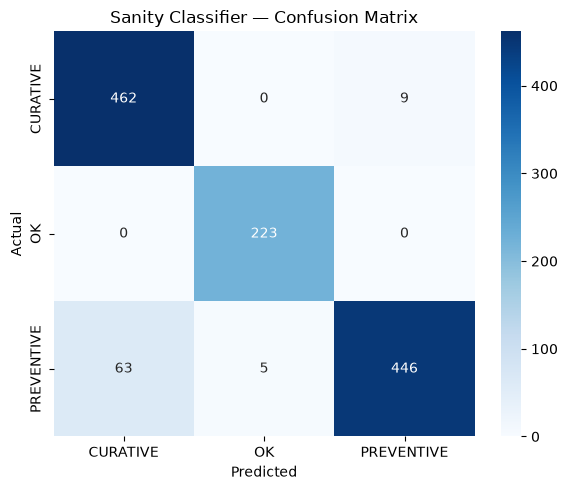

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_confusion_matrix(y_true, y_pred, labels, title):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(y_test, y_pred_rf, rf.classes_, "FH RSL Classifier — Confusion Matrix")
plot_confusion_matrix(y_test_s, y_pred_rf_s, rf_sanity.classes_, "Sanity Classifier — Confusion Matrix")

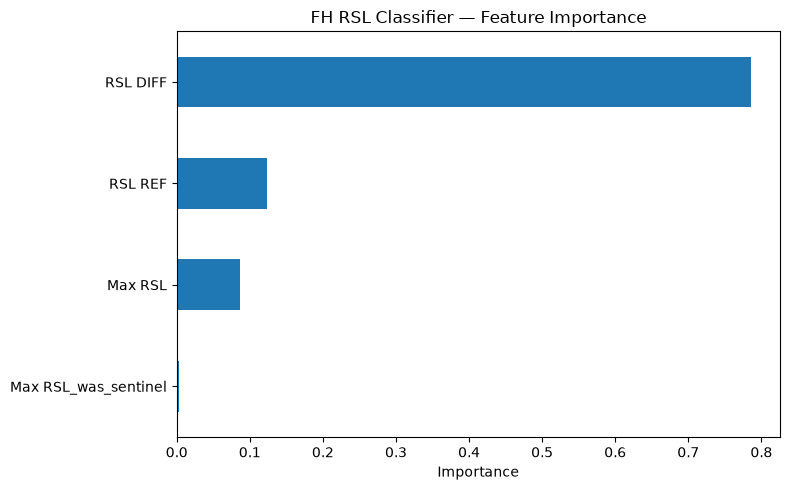

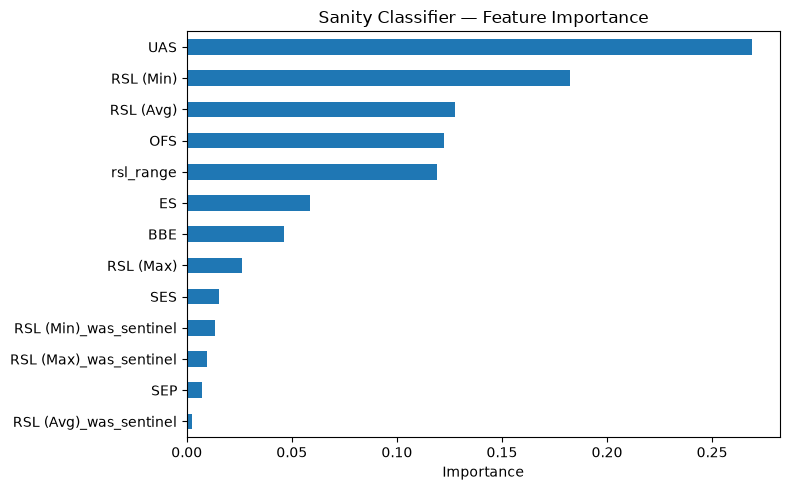

In [22]:
def plot_feature_importance(importances, title):
    plt.figure(figsize=(8, 5))
    importances.sort_values().plot(kind="barh")
    plt.title(title)
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()

plot_feature_importance(importances, "FH RSL Classifier — Feature Importance")
plot_feature_importance(importances_s, "Sanity Classifier — Feature Importance")

# Modeling: Anomaly Detection (RXLev, RTWP)
**Goal:** Flag unusual links/cells without labeled data, using Isolation Forest.
**Inputs:** data/processed/rxlev_features.csv, data/processed/rtwp_features.csv

1. Setup

In [18]:
import pandas as pd
from pathlib import Path
from sklearn.ensemble import IsolationForest
import joblib

PROCESSED_DIR = Path("../data/processed")

2. RXLev anomaly detection

In [19]:
df_rxlev = pd.read_csv(PROCESSED_DIR / "rxlev_features.csv")
print(df_rxlev.shape)
print(df_rxlev.columns.tolist())

rxlev_features = ["Min RSL", "Avg RSL", "Max RSL", "rsl_range"]
X_rxlev = df_rxlev[rxlev_features].fillna(df_rxlev[rxlev_features].median())

iso_rxlev = IsolationForest(n_estimators=200, contamination=0.05, random_state=42)
iso_rxlev.fit(X_rxlev)

df_rxlev["anomaly_score"] = iso_rxlev.decision_function(X_rxlev)
df_rxlev["is_anomaly"] = iso_rxlev.predict(X_rxlev) == -1

print("flagged anomalies:", df_rxlev["is_anomaly"].sum(), "/", len(df_rxlev))
print()
print("--- most anomalous rows ---")
display(df_rxlev.sort_values("anomaly_score").head(10)[["Name", "IP"] + rxlev_features + ["anomaly_score"]])

(6016, 10)
['Name', 'IP', 'Slot', 'Min RSL', 'Avg RSL', 'Max RSL', 'Min RSL_was_sentinel', 'Avg RSL_was_sentinel', 'Max RSL_was_sentinel', 'rsl_range']
flagged anomalies: 301 / 6016

--- most anomalous rows ---


,Name,IP,Min RSL,Avg RSL,Max RSL,rsl_range,anomaly_score
973,MAH_0054_ETTAWAFAK_Mahdia,172.18.2.46,-98.4,-97.59,-97.0,1.4,-0.233888
1265,TUN_0135_TUN_0333_STIMM,172.18.196.37,-96.8,-96.31,-95.8,1.0,-0.232567
995,TUN_0005_TUN_0113_TIMSOFT,172.18.24.14,-98.2,-97.20,-96.0,2.2,-0.232039
1340,MAN_0030_B2B_SEBN_TN2,172.18.214.37,-96.5,-95.78,-95.0,1.5,-0.230720
1857,BAR_0104_BAR_0103_SICAP_SSOMY,172.18.162.1,-94.3,-93.65,-93.0,1.3,-0.228879
1914,BAR_0068_SUPPLYTRONIC_STBG,172.19.198.18,-94.1,-93.36,-92.8,1.3,-0.228879
1839,SFA_0104_PETROFAC,172.18.46.59,-94.4,-93.72,-93.2,1.2,-0.228353
1787,TUN_0011_ZITOUNA,172.18.140.7,-94.6,-94.08,-93.4,1.2,-0.228353
1463,BAR_0060_BAR_0046_BAR_0151_AZUR,172.19.74.1,-96.0,-94.44,-92.8,3.2,-0.227566
1057,KAI_0016_UIB AGENCE KAIROUAN,172.18.144.9,-97.8,-96.26,-93.8,4.0,-0.227478


3. RTWP anomaly detection

In [20]:
df_rtwp = pd.read_csv(PROCESSED_DIR / "rtwp_features.csv")
print(df_rtwp.shape)
print(df_rtwp.columns.tolist())

rtwp_features = ["mean_rtwp", "max_rtwp", "min_rtwp", "occ_rtwp_gt_98",
                  "antenna_imbalance", "rtwp_range", "occ_diff_sect_gt_5"]
X_rtwp = df_rtwp[rtwp_features].fillna(df_rtwp[rtwp_features].median())

iso_rtwp = IsolationForest(n_estimators=200, contamination=0.05, random_state=42)
iso_rtwp.fit(X_rtwp)

df_rtwp["anomaly_score"] = iso_rtwp.decision_function(X_rtwp)
df_rtwp["is_anomaly"] = iso_rtwp.predict(X_rtwp) == -1

print("flagged anomalies:", df_rtwp["is_anomaly"].sum(), "/", len(df_rtwp))
print()
print("--- most anomalous rows ---")
display(df_rtwp.sort_values("anomaly_score").head(10)[["Cell_Name"] + rtwp_features + ["anomaly_score"]])

(295, 10)
['Cell_Name', 'mean_rtwp', 'max_rtwp', 'min_rtwp', 'occ_rtwp_gt_98', 'vs_mean_rtwp_ant0', 'vs_mean_rtwp_ant1', 'occ_diff_sect_gt_5', 'antenna_imbalance', 'rtwp_range']
flagged anomalies: 15 / 295

--- most anomalous rows ---


,Cell_Name,mean_rtwp,max_rtwp,min_rtwp,occ_rtwp_gt_98,antenna_imbalance,rtwp_range,occ_diff_sect_gt_5,anomaly_score
100,BIZ_0097_C03_412_u6,-76.2278,-73.0023,-80.0198,63,3.1103,7.0175,0,-0.157410
114,GAB_0060_C02_413_w3,-85.2075,-80.8510,-91.6028,63,7.1960,10.7518,63,-0.090163
99,BIZ_0095_C03_113_v8,-82.2440,-81.0833,-84.9791,63,1.9314,3.8958,0,-0.087512
95,BIZ_0026_C01_409_v7,-93.0197,-91.2256,-94.8067,63,12.3981,3.5811,63,-0.056674
252,TUN_0131_C01_309_w3,-96.8262,-72.4186,-102.1680,38,4.8971,29.7494,33,-0.042182
98,BIZ_0095_C03_113_v7,-89.9928,-88.8701,-91.9563,63,5.9343,3.0862,55,-0.039226
37,ARI_0166_C03_116_w2,-98.1794,-78.0766,-105.9960,34,7.7390,27.9194,52,-0.033540
36,ARI_0166_C03_116_v8,-98.1939,-77.9702,-105.8630,34,7.5986,27.8928,47,-0.020874
87,BAR_0166_C04_418_w3,-92.9999,-89.1129,-98.5858,62,11.0739,9.4729,63,-0.016389
164,MON_0129_C01_221_v7,-96.7174,-95.6290,-100.1540,57,9.8282,4.5250,63,-0.014102


In [21]:
model_path_rxlev = Path("../models/rxlev_anomaly_model.pkl")
joblib.dump(iso_rxlev, model_path_rxlev)
print("saved:", model_path_rxlev.resolve())

model_path_rtwp = Path("../models/rtwp_anomaly_model.pkl")
joblib.dump(iso_rtwp, model_path_rtwp)
print("saved:", model_path_rtwp.resolve())

saved: C:\OrangeCopilot\projet_pfe-main (1)\projet_pfe-main\main\FH\AI\models\rxlev_anomaly_model.pkl
saved: C:\OrangeCopilot\projet_pfe-main (1)\projet_pfe-main\main\FH\AI\models\rtwp_anomaly_model.pkl
